In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("/content/manufacturing_quality_dataset_final.csv")

In [3]:
df.head()

,Prediction_ID,Timestamp,Machine_ID,Product_ID,Product_Type,Operator_ID,Air_Temp_C,Process_Temp_C,Vibration_Hz,Network_Latency_ms,Torque_Nm,Tool_Wear_min,Rolling_Vibration_1h,Temp_Diff,Image_Path,Defect_Class,Is_Defective
0,0339220b-969f-4076-9507-5a2e50846ed4,2023-01-01 08:00:00,M-007,PRD-000001,M,OP-08,22.206172,34.354794,29.550835,12.512171,42.477949,120,29.550835,12.148622,s3://manufacturing-quality-images/images/M-007...,Good,False
1,2b35b2f0-8940-4cb1-a42f-e29431bfef40,2023-01-01 08:15:00,M-004,PRD-000002,M,OP-13,26.620488,38.578851,38.032530,18.661502,36.220703,161,38.032530,11.958363,s3://manufacturing-quality-images/images/M-004...,Surface Defect,True
2,701be612-fda3-4db7-9292-f692ba92f074,2023-01-01 08:30:00,M-008,PRD-000003,L,OP-04,25.946717,33.003705,33.441611,11.871884,38.956066,59,33.441611,7.056988,s3://manufacturing-quality-images/images/M-008...,Good,False
3,ad9fb721-1ea6-4468-bf77-b0fe892e0571,2023-01-01 08:45:00,M-005,PRD-000004,L,OP-10,23.851211,36.230955,36.098194,23.315850,34.328736,236,36.098194,12.379745,s3://manufacturing-quality-images/images/M-005...,Good,False
4,7142f4ef-6952-4039-a0ae-06fe19d696e1,2023-01-01 09:00:00,M-007,PRD-000005,L,OP-05,26.282349,40.327095,32.561707,25.290095,34.541800,178,31.056271,14.044746,s3://manufacturing-quality-images/images/M-007...,Good,False


In [4]:
df.shape

(5000, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Prediction_ID         5000 non-null   object 
 1   Timestamp             5000 non-null   object 
 2   Machine_ID            5000 non-null   object 
 3   Product_ID            5000 non-null   object 
 4   Product_Type          5000 non-null   object 
 5   Operator_ID           5000 non-null   object 
 6   Air_Temp_C            5000 non-null   float64
 7   Process_Temp_C        5000 non-null   float64
 8   Vibration_Hz          5000 non-null   float64
 9   Network_Latency_ms    5000 non-null   float64
 10  Torque_Nm             5000 non-null   float64
 11  Tool_Wear_min         5000 non-null   int64  
 12  Rolling_Vibration_1h  5000 non-null   float64
 13  Temp_Diff             5000 non-null   float64
 14  Image_Path            5000 non-null   object 
 15  Defect_Class         

In [6]:
df.describe()

,Air_Temp_C,Process_Temp_C,Vibration_Hz,Network_Latency_ms,Torque_Nm,Tool_Wear_min,Rolling_Vibration_1h,Temp_Diff
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.989054,36.817393,32.435585,20.065917,42.446996,124.318800,32.432993,11.828339
std,1.501674,2.671624,5.254022,15.177747,7.213685,72.151773,2.622897,2.223900
min,20.200359,27.340611,16.554046,5.000139,22.335909,0.000000,20.981898,3.309910
25%,23.937286,34.975045,28.535763,9.299561,37.375014,62.000000,30.634968,10.310351
50%,24.990018,36.807159,32.468020,15.236747,41.509764,122.000000,32.458583,11.823730
75%,25.993757,38.613244,36.350457,25.885719,46.641067,187.000000,34.242292,13.372389
max,29.776460,47.815301,47.055520,126.419691,70.512075,249.000000,42.208386,20.507700


In [7]:
df.isnull().sum()

,0
Prediction_ID,0
Timestamp,0
Machine_ID,0
Product_ID,0
Product_Type,0
Operator_ID,0
Air_Temp_C,0
Process_Temp_C,0
Vibration_Hz,0
Network_Latency_ms,0


In [8]:
df.columns

Index(['Prediction_ID', 'Timestamp', 'Machine_ID', 'Product_ID',
       'Product_Type', 'Operator_ID', 'Air_Temp_C', 'Process_Temp_C',
       'Vibration_Hz', 'Network_Latency_ms', 'Torque_Nm', 'Tool_Wear_min',
       'Rolling_Vibration_1h', 'Temp_Diff', 'Image_Path', 'Defect_Class',
       'Is_Defective'],
      dtype='object')

In [9]:
df.dtypes

,0
Prediction_ID,object
Timestamp,object
Machine_ID,object
Product_ID,object
Product_Type,object
Operator_ID,object
Air_Temp_C,float64
Process_Temp_C,float64
Vibration_Hz,float64
Network_Latency_ms,float64


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.select_dtypes(include= "object"):
  print(col)
  print(df[col].unique())
  print("-"*40)

Prediction_ID
['0339220b-969f-4076-9507-5a2e50846ed4'
 '2b35b2f0-8940-4cb1-a42f-e29431bfef40'
 '701be612-fda3-4db7-9292-f692ba92f074' ...
 'e8e657d1-e2e6-4988-912f-245ffd77eca1'
 'f50f42de-7571-43e4-b61f-481e3c83d58d'
 '49d56e29-eb8c-48f4-a0d6-d23fcb67ed7e']
----------------------------------------
Timestamp
['2023-01-01 08:00:00' '2023-01-01 08:15:00' '2023-01-01 08:30:00' ...
 '2023-02-22 09:15:00' '2023-02-22 09:30:00' '2023-02-22 09:45:00']
----------------------------------------
Machine_ID
['M-007' 'M-004' 'M-008' 'M-005' 'M-010' 'M-003' 'M-006' 'M-002' 'M-001'
 'M-009']
----------------------------------------
Product_ID
['PRD-000001' 'PRD-000002' 'PRD-000003' ... 'PRD-004998' 'PRD-004999'
 'PRD-005000']
----------------------------------------
Product_Type
['M' 'L' 'H']
----------------------------------------
Operator_ID
['OP-08' 'OP-13' 'OP-04' 'OP-10' 'OP-05' 'OP-02' 'OP-15' 'OP-12' 'OP-01'
 'OP-09' 'OP-06' 'OP-11' 'OP-07' 'OP-14' 'OP-03']
-----------------------------------

In [12]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [13]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df[col].nunique())

Prediction_ID
5000
Timestamp
5000
Machine_ID
10
Product_ID
5000
Product_Type
3
Operator_ID
15
Air_Temp_C
5000
Process_Temp_C
5000
Vibration_Hz
5000
Network_Latency_ms
5000
Torque_Nm
5000
Tool_Wear_min
250
Rolling_Vibration_1h
5000
Temp_Diff
5000
Image_Path
5000
Defect_Class
7
Is_Defective
2


In [14]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    print("="*40)
    print(col)

    print(df[col].value_counts())

Prediction_ID
Prediction_ID
49d56e29-eb8c-48f4-a0d6-d23fcb67ed7e    1
0339220b-969f-4076-9507-5a2e50846ed4    1
2b35b2f0-8940-4cb1-a42f-e29431bfef40    1
701be612-fda3-4db7-9292-f692ba92f074    1
ad9fb721-1ea6-4468-bf77-b0fe892e0571    1
                                       ..
37cdb477-90bf-4893-9583-1bf6e1233796    1
65e57bf7-a9ad-4c44-9b32-ff157a1f8301    1
4ae44c3c-3252-4b53-95cd-61cd883a3fc4    1
34db29a5-5bc0-41f5-8ef8-809ade96d1e7    1
36146544-f524-49a8-b265-36875a410773    1
Name: count, Length: 5000, dtype: int64
Machine_ID
Machine_ID
M-001    533
M-008    516
M-006    513
M-003    513
M-005    507
M-010    496
M-009    486
M-004    486
M-007    480
M-002    470
Name: count, dtype: int64
Product_ID
Product_ID
PRD-005000    1
PRD-000001    1
PRD-000002    1
PRD-000003    1
PRD-000004    1
             ..
PRD-000013    1
PRD-000012    1
PRD-000011    1
PRD-000010    1
PRD-000009    1
Name: count, Length: 5000, dtype: int64
Product_Type
Product_Type
L    2499
M    1499
H    100

In [15]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Prediction_ID         5000 non-null   object        
 1   Timestamp             5000 non-null   datetime64[ns]
 2   Machine_ID            5000 non-null   object        
 3   Product_ID            5000 non-null   object        
 4   Product_Type          5000 non-null   object        
 5   Operator_ID           5000 non-null   object        
 6   Air_Temp_C            5000 non-null   float64       
 7   Process_Temp_C        5000 non-null   float64       
 8   Vibration_Hz          5000 non-null   float64       
 9   Network_Latency_ms    5000 non-null   float64       
 10  Torque_Nm             5000 non-null   float64       
 11  Tool_Wear_min         5000 non-null   int64         
 12  Rolling_Vibration_1h  5000 non-null   float64       
 13  Temp_Diff         

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

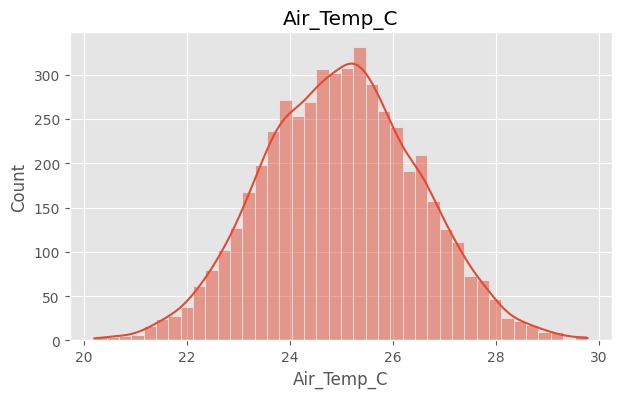

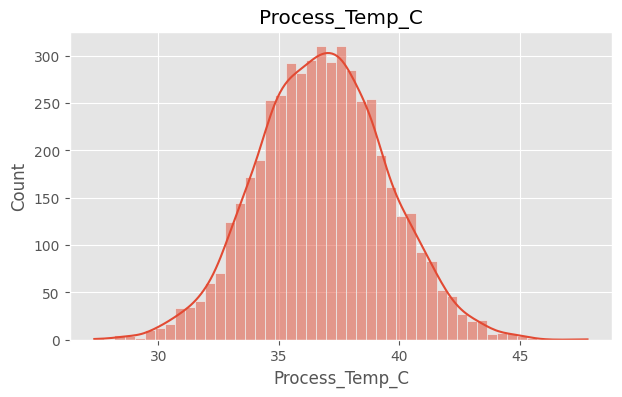

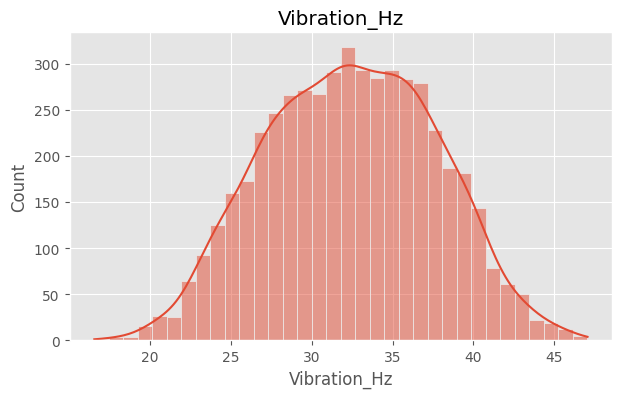

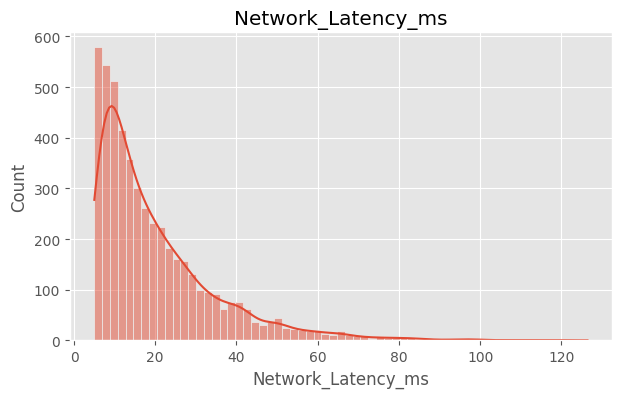

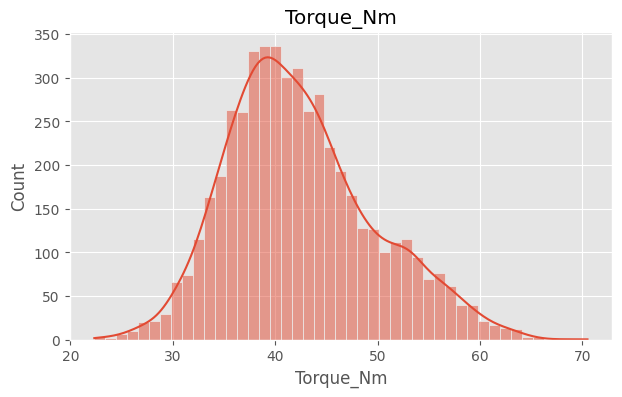

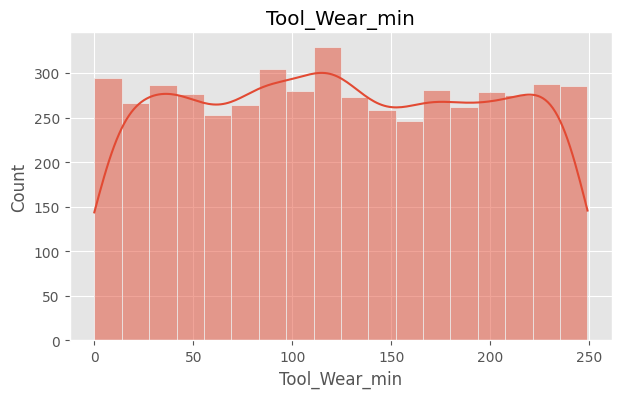

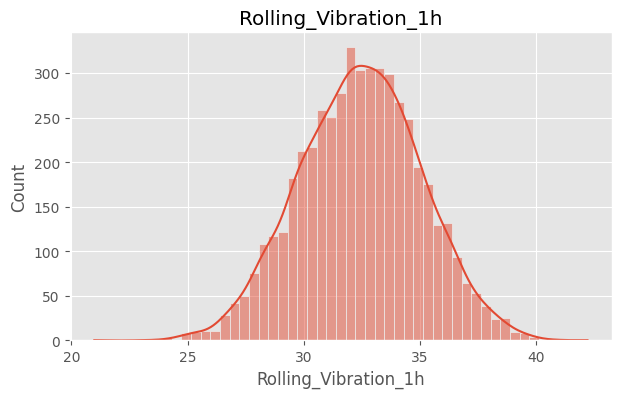

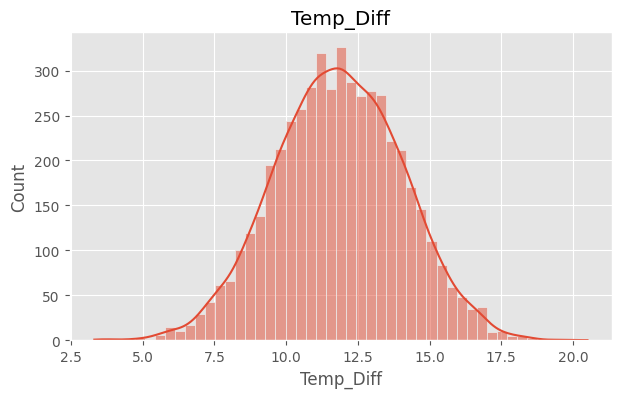

In [19]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

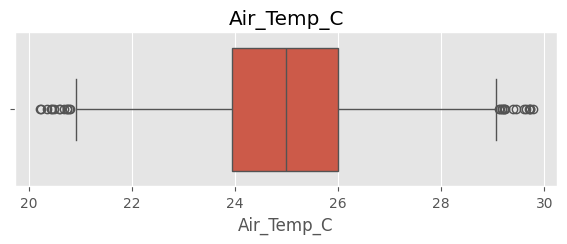

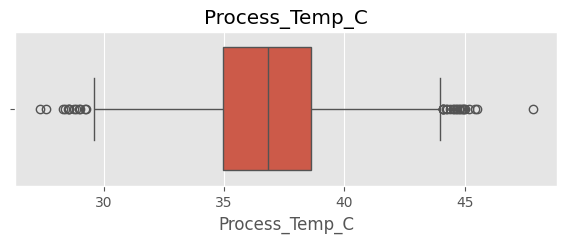

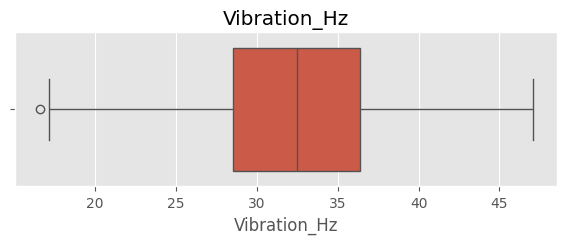

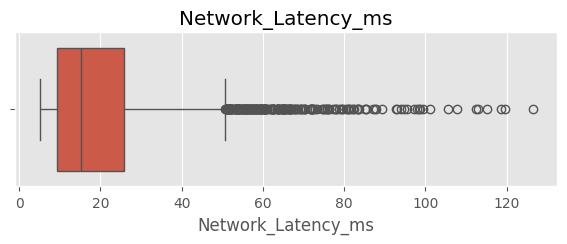

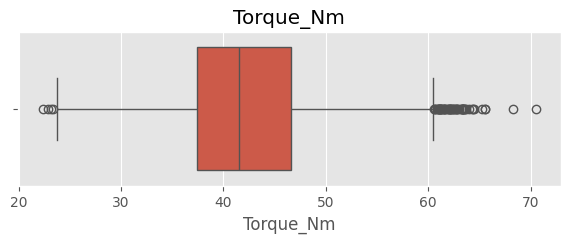

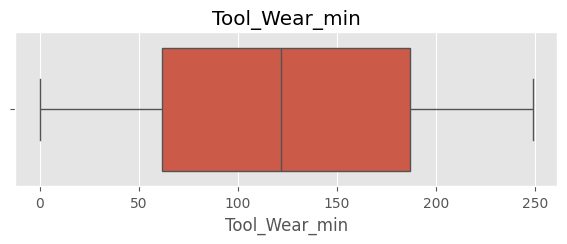

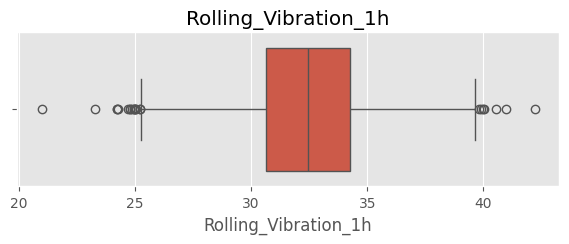

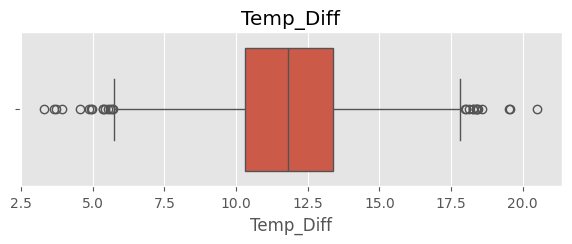

In [20]:
for col in num_cols:
    plt.figure(figsize=(7,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [21]:
target = "Is_Defective"

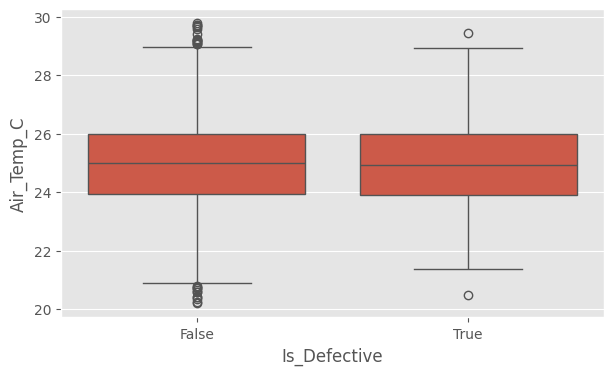

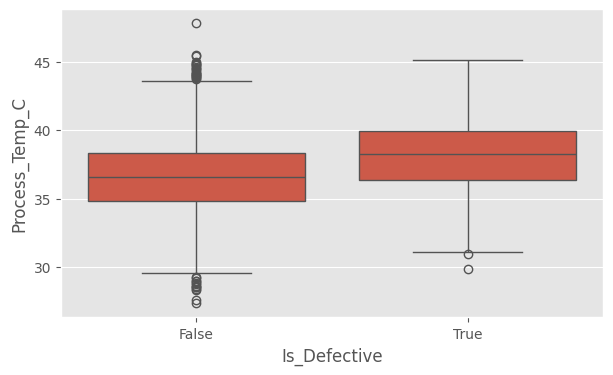

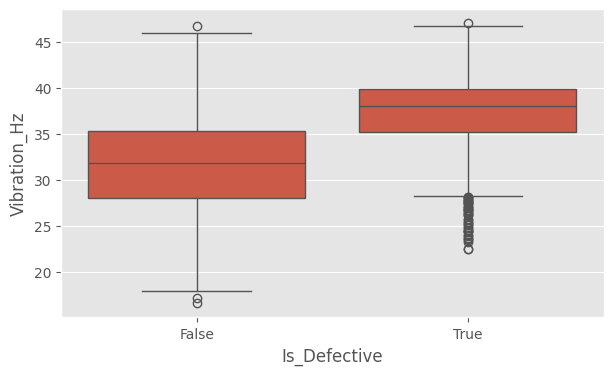

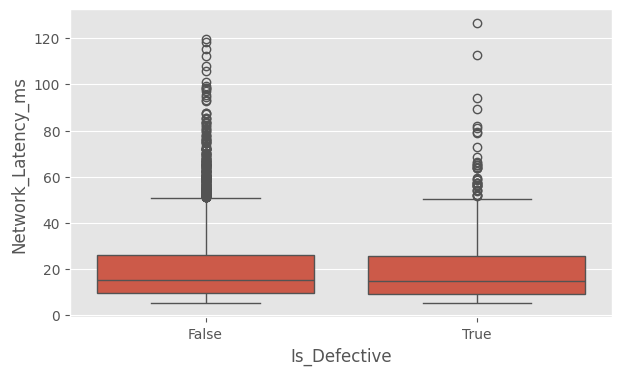

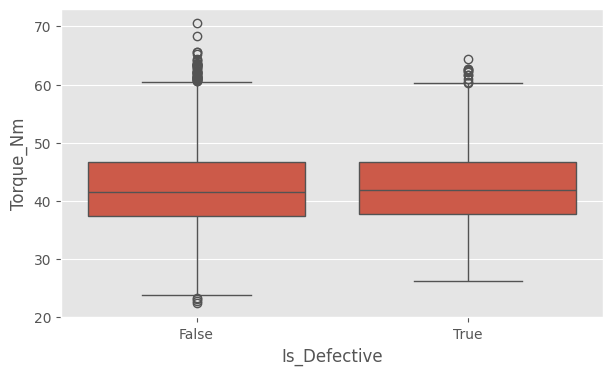

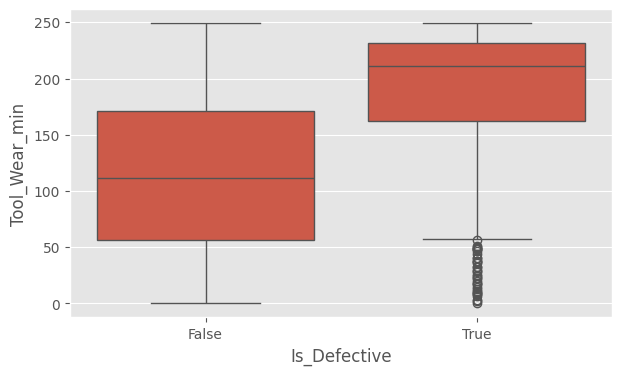

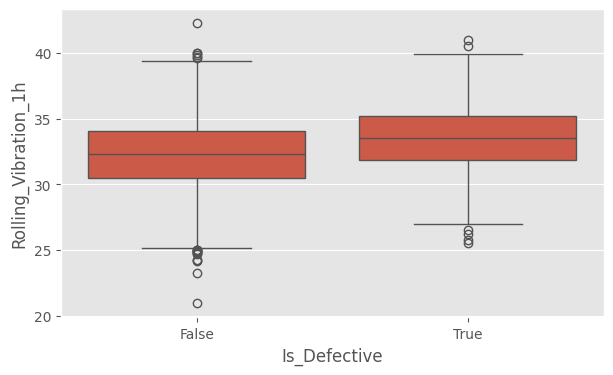

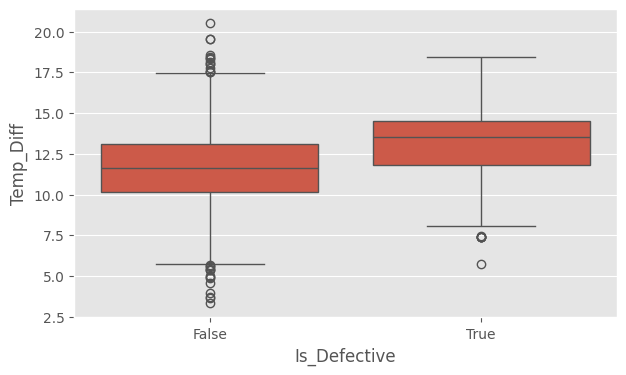

In [22]:
for col in num_cols:
    if col != target:
        plt.figure(figsize=(7,4))
        sns.boxplot(
            x=target,
            y=col,
            data=df
        )

        plt.show()

In [23]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month_name()
df["Week"] = df["Timestamp"].dt.isocalendar().week
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour

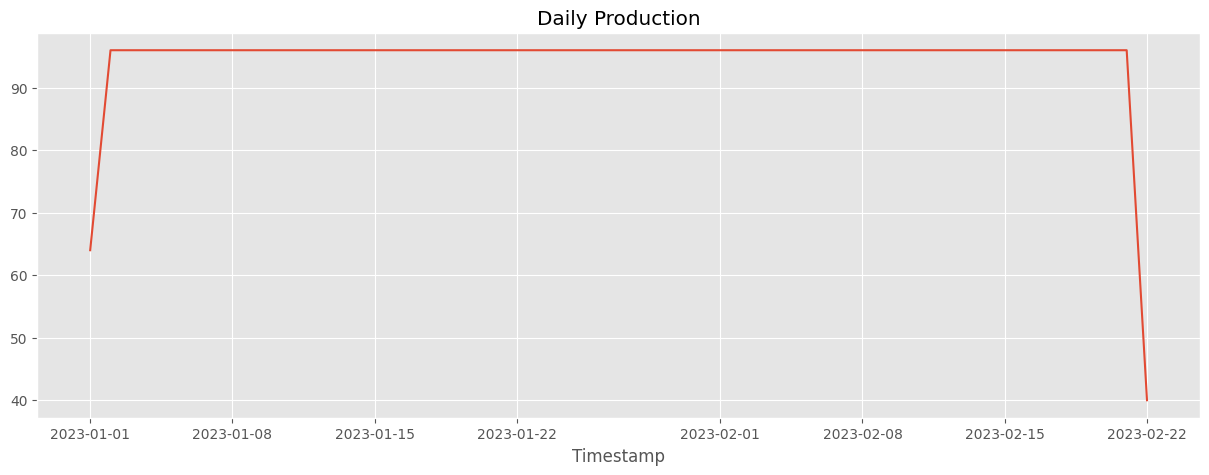

In [24]:
daily = df.groupby(df["Timestamp"].dt.date).size()
plt.figure(figsize=(15,5))
daily.plot()

plt.title("Daily Production")
plt.show()

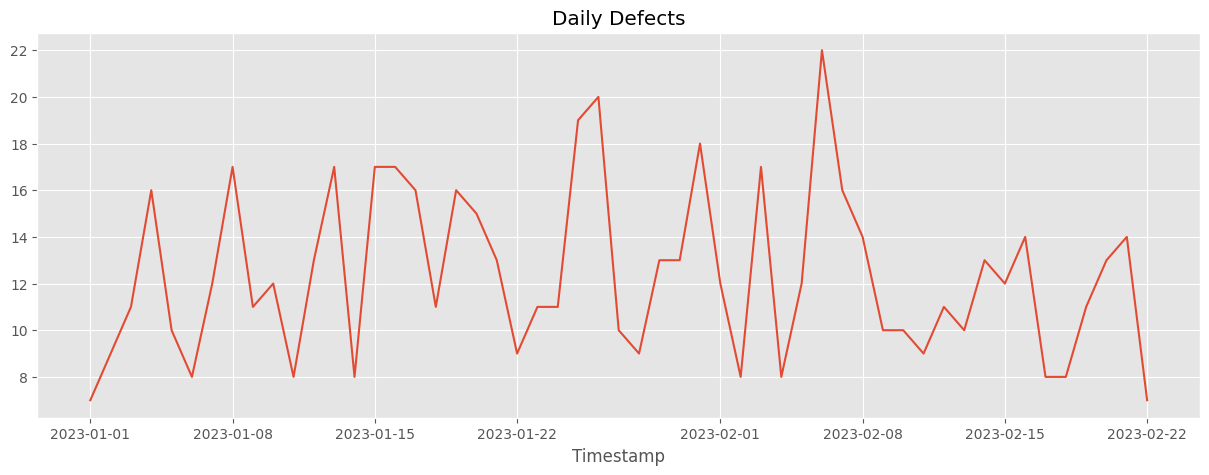

In [25]:
daily_defects = df[df["Is_Defective"]==1]

daily_defects.groupby(
    daily_defects["Timestamp"].dt.date
).size().plot(figsize=(15,5))

plt.title("Daily Defects")
plt.show()

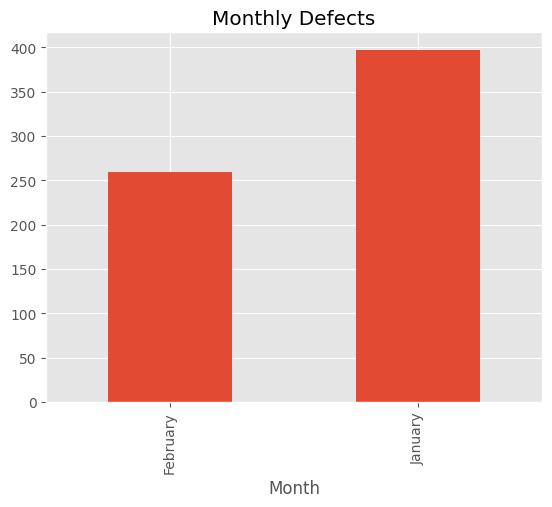

In [26]:
monthly = df.groupby("Month")["Is_Defective"].sum()
monthly.plot(kind="bar")
plt.title("Monthly Defects")
plt.show()

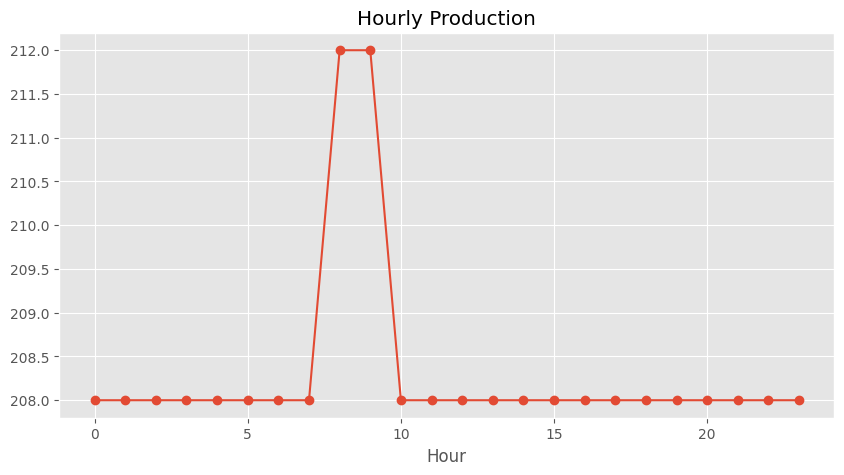

In [27]:
hourly = df.groupby("Hour").size()

hourly.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Hourly Production")
plt.show()

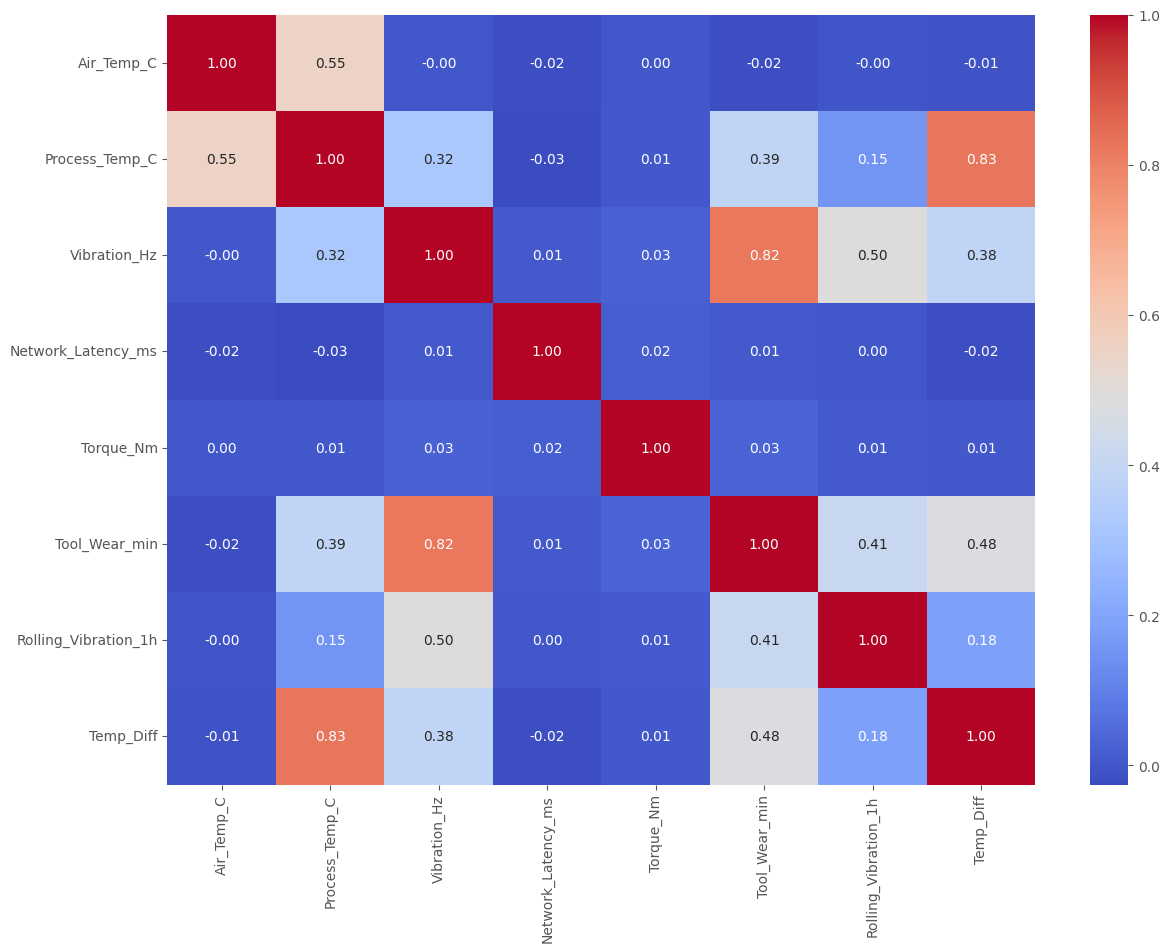

In [28]:
corr = df[num_cols].corr()
plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [29]:
df[num_cols].skew()

,0
Air_Temp_C,0.034512
Process_Temp_C,0.044858
Vibration_Hz,-0.020007
Network_Latency_ms,1.969358
Torque_Nm,0.506101
Tool_Wear_min,0.013556
Rolling_Vibration_1h,-0.050592
Temp_Diff,-0.034187


In [30]:
df[num_cols].kurtosis()

,0
Air_Temp_C,-0.132159
Process_Temp_C,0.026540
Vibration_Hz,-0.540976
Network_Latency_ms,5.409194
Torque_Nm,0.004932
Tool_Wear_min,-1.187210
Rolling_Vibration_1h,-0.085107
Temp_Diff,-0.022143


In [31]:
temp_df = df[num_cols].copy()
temp_df['Is_Defective'] = df['Is_Defective'].astype(int)
corr_with_target = temp_df.corr()['Is_Defective'].sort_values(ascending=False)
print(corr_with_target)

Is_Defective            1.000000
Vibration_Hz            0.342154
Tool_Wear_min           0.336349
Temp_Diff               0.233222
Process_Temp_C          0.190085
Rolling_Vibration_1h    0.159584
Torque_Nm               0.009768
Network_Latency_ms      0.001743
Air_Temp_C             -0.007211
Name: Is_Defective, dtype: float64


In [32]:
df.to_csv(
    "manufacturing_clean.csv",
    index=False
)


In [33]:
df.head()

,Prediction_ID,Timestamp,Machine_ID,Product_ID,Product_Type,Operator_ID,Air_Temp_C,Process_Temp_C,Vibration_Hz,Network_Latency_ms,Torque_Nm,Tool_Wear_min,Rolling_Vibration_1h,Temp_Diff,Image_Path,Defect_Class,Is_Defective,Year,Month,Week,Day,Hour
0,0339220b-969f-4076-9507-5a2e50846ed4,2023-01-01 08:00:00,M-007,PRD-000001,M,OP-08,22.206172,34.354794,29.550835,12.512171,42.477949,120,29.550835,12.148622,s3://manufacturing-quality-images/images/M-007...,Good,False,2023,January,52,1,8
1,2b35b2f0-8940-4cb1-a42f-e29431bfef40,2023-01-01 08:15:00,M-004,PRD-000002,M,OP-13,26.620488,38.578851,38.032530,18.661502,36.220703,161,38.032530,11.958363,s3://manufacturing-quality-images/images/M-004...,Surface Defect,True,2023,January,52,1,8
2,701be612-fda3-4db7-9292-f692ba92f074,2023-01-01 08:30:00,M-008,PRD-000003,L,OP-04,25.946717,33.003705,33.441611,11.871884,38.956066,59,33.441611,7.056988,s3://manufacturing-quality-images/images/M-008...,Good,False,2023,January,52,1,8
3,ad9fb721-1ea6-4468-bf77-b0fe892e0571,2023-01-01 08:45:00,M-005,PRD-000004,L,OP-10,23.851211,36.230955,36.098194,23.315850,34.328736,236,36.098194,12.379745,s3://manufacturing-quality-images/images/M-005...,Good,False,2023,January,52,1,8
4,7142f4ef-6952-4039-a0ae-06fe19d696e1,2023-01-01 09:00:00,M-007,PRD-000005,L,OP-05,26.282349,40.327095,32.561707,25.290095,34.541800,178,31.056271,14.044746,s3://manufacturing-quality-images/images/M-007...,Good,False,2023,January,52,1,9


In [34]:
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import zscore

In [35]:
df = pd.read_csv("/content/manufacturing_clean.csv")

In [36]:
df.head()

,Prediction_ID,Timestamp,Machine_ID,Product_ID,Product_Type,Operator_ID,Air_Temp_C,Process_Temp_C,Vibration_Hz,Network_Latency_ms,Torque_Nm,Tool_Wear_min,Rolling_Vibration_1h,Temp_Diff,Image_Path,Defect_Class,Is_Defective,Year,Month,Week,Day,Hour
0,0339220b-969f-4076-9507-5a2e50846ed4,2023-01-01 08:00:00,M-007,PRD-000001,M,OP-08,22.206172,34.354794,29.550835,12.512171,42.477949,120,29.550835,12.148622,s3://manufacturing-quality-images/images/M-007...,Good,False,2023,January,52,1,8
1,2b35b2f0-8940-4cb1-a42f-e29431bfef40,2023-01-01 08:15:00,M-004,PRD-000002,M,OP-13,26.620488,38.578851,38.032530,18.661502,36.220703,161,38.032530,11.958363,s3://manufacturing-quality-images/images/M-004...,Surface Defect,True,2023,January,52,1,8
2,701be612-fda3-4db7-9292-f692ba92f074,2023-01-01 08:30:00,M-008,PRD-000003,L,OP-04,25.946717,33.003705,33.441611,11.871884,38.956066,59,33.441611,7.056988,s3://manufacturing-quality-images/images/M-008...,Good,False,2023,January,52,1,8
3,ad9fb721-1ea6-4468-bf77-b0fe892e0571,2023-01-01 08:45:00,M-005,PRD-000004,L,OP-10,23.851211,36.230955,36.098194,23.315850,34.328736,236,36.098194,12.379745,s3://manufacturing-quality-images/images/M-005...,Good,False,2023,January,52,1,8
4,7142f4ef-6952-4039-a0ae-06fe19d696e1,2023-01-01 09:00:00,M-007,PRD-000005,L,OP-05,26.282349,40.327095,32.561707,25.290095,34.541800,178,31.056271,14.044746,s3://manufacturing-quality-images/images/M-007...,Good,False,2023,January,52,1,9


In [37]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [38]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Week"] = df["Timestamp"].dt.isocalendar().week.astype(int)
df["Day"] = df["Timestamp"].dt.day
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Hour"] = df["Timestamp"].dt.hour
df["Quarter"] = df["Timestamp"].dt.quarter
df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

In [39]:
df["Temperature_Difference"] = (
    df["Process_Temp_C"] -
    df["Air_Temp_C"]
)

In [40]:
df["Tool_Wear_Category"] = pd.cut(
    df["Tool_Wear_min"],
    bins=[0,80,160,240],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [41]:
df["High_Vibration"] = (
    df["Vibration_Hz"] >
    df["Vibration_Hz"].median()
).astype(int)

In [42]:
df["High_Temperature"] = (
    df["Process_Temp_C"] >
    df["Process_Temp_C"].median()
).astype(int)

In [43]:
df["Machine_Load_Index"] = (
    df["Torque_Nm"] *
    df["Vibration_Hz"]
)

In [44]:
df["Thermal_Stress"] = (
    df["Temperature_Difference"] *
    df["Torque_Nm"]
)

In [45]:
df["Wear_Rate"] = (
    df["Tool_Wear_min"] /
    (df["Torque_Nm"] + 1)
)

In [46]:
def shift(hour):

    if 6 <= hour < 14:
        return "Morning"

    elif 14 <= hour < 22:
        return "Evening"

    else:
        return "Night"

df["Shift"] = df["Hour"].apply(shift)

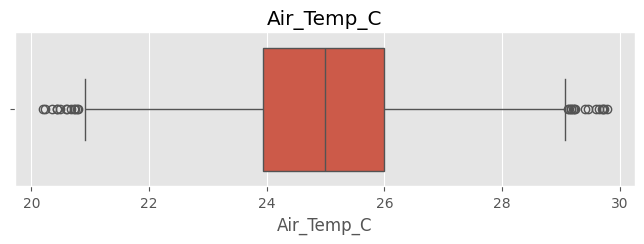

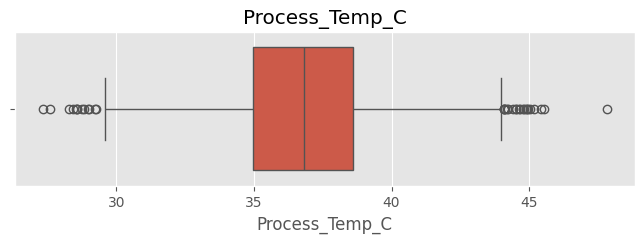

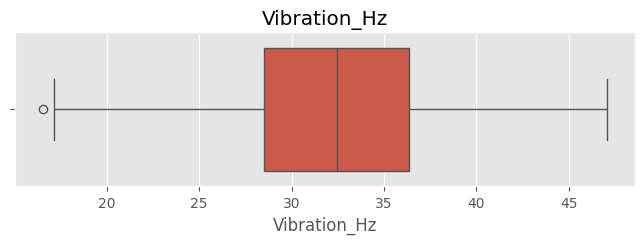

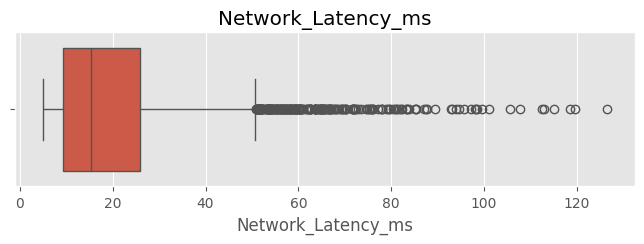

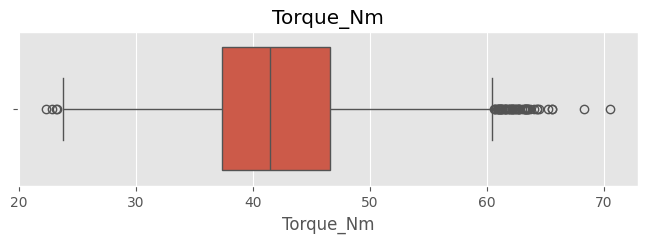

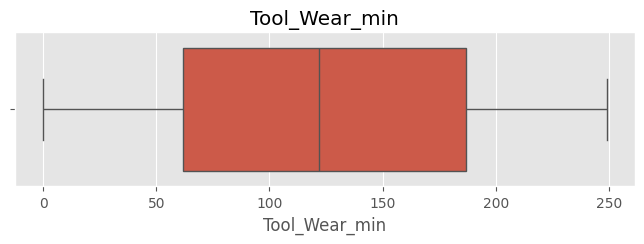

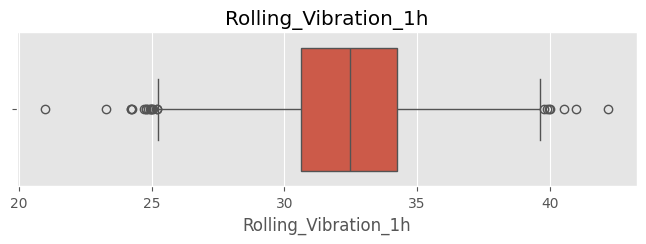

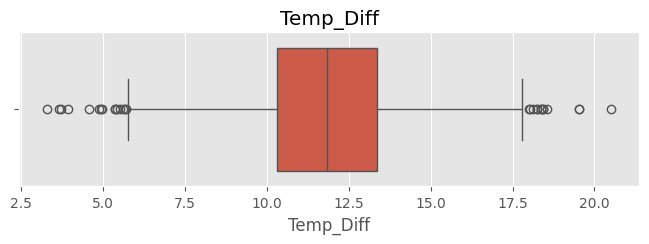

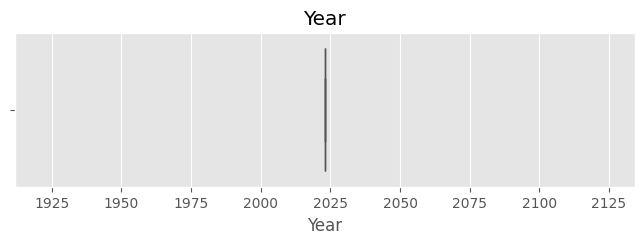

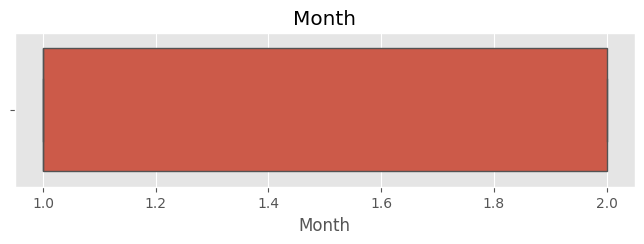

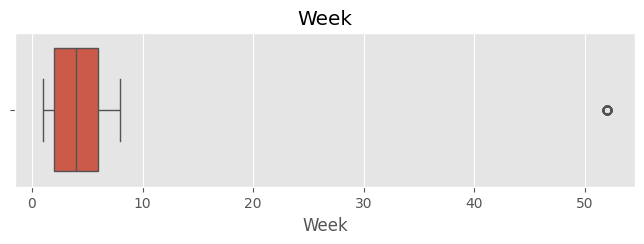

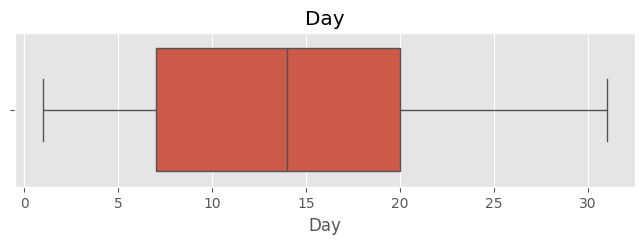

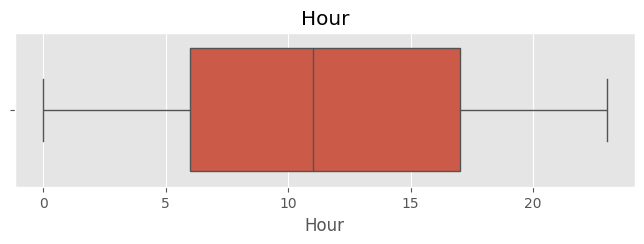

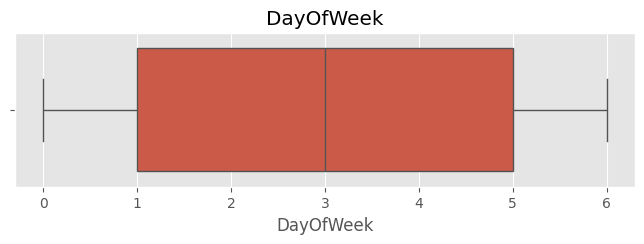

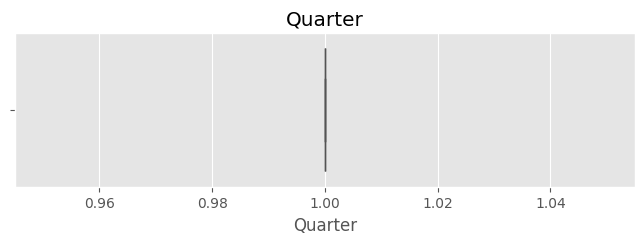

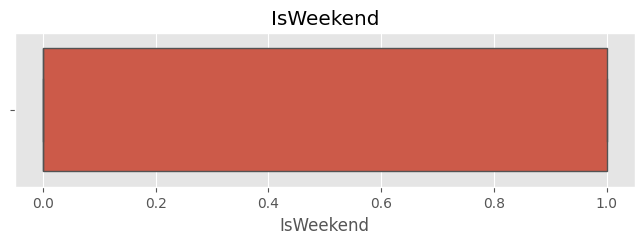

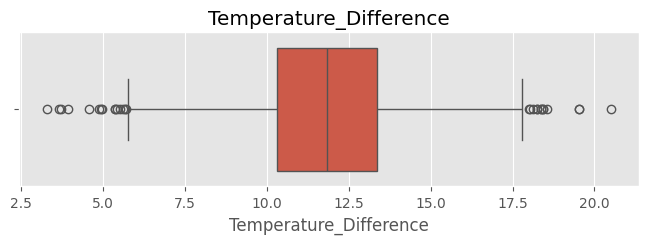

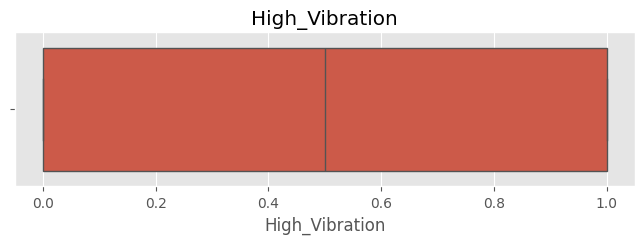

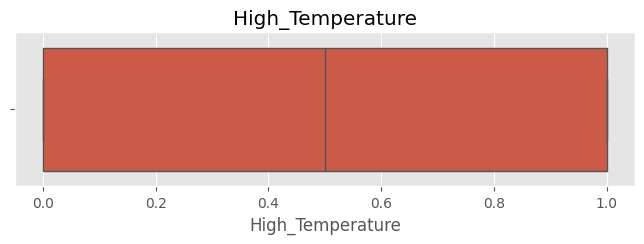

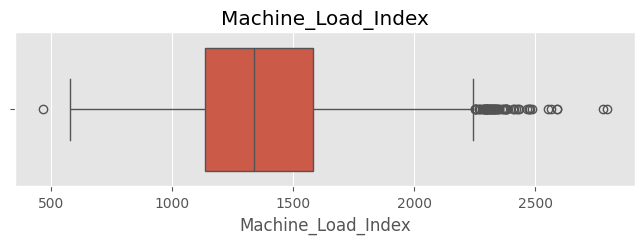

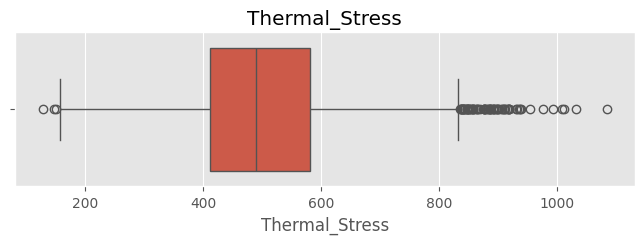

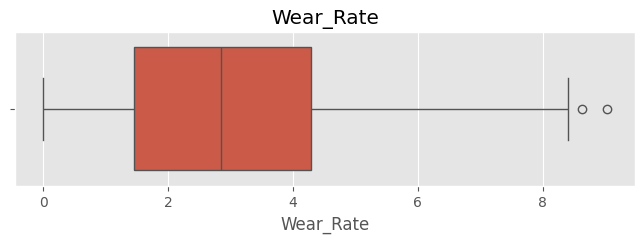

In [47]:
num_cols = df.select_dtypes(
    include=np.number
).columns

for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(
        x=df[col]
    )

    plt.title(col)
    plt.show()

In [48]:
def remove_outliers(data,column):
    q1 = data[column].quantile(.25)
    q3 = data[column].quantile(.75)

    iqr = q3-q1
    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    return data[
        (data[column]>=lower) &
        (data[column]<=upper)
    ]

In [49]:
df.drop(
    columns=[
        "Timestamp",
        "Image_Path",
        "Prediction_ID"
    ],
    inplace=True
)

In [50]:
encoder = LabelEncoder()

categorical = df.select_dtypes(
    include="object"
).columns

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [51]:
X = df.drop(
    "Is_Defective",
    axis=1
)

y = df["Is_Defective"]

In [52]:
encoder = LabelEncoder()


object_and_category_cols_in_X = X.select_dtypes(include=['object', 'category']).columns

for col in object_and_category_cols_in_X:
    X[col] = encoder.fit_transform(X[col])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [53]:
mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X.columns
).sort_values(
    ascending=False
)

mi_scores

,0
Defect_Class,0.388862
Vibration_Hz,0.075927
Tool_Wear_min,0.067749
Tool_Wear_Category,0.058466
Wear_Rate,0.050647
Machine_Load_Index,0.033433
Temperature_Difference,0.033227
Temp_Diff,0.033227
High_Vibration,0.032841
Process_Temp_C,0.021434


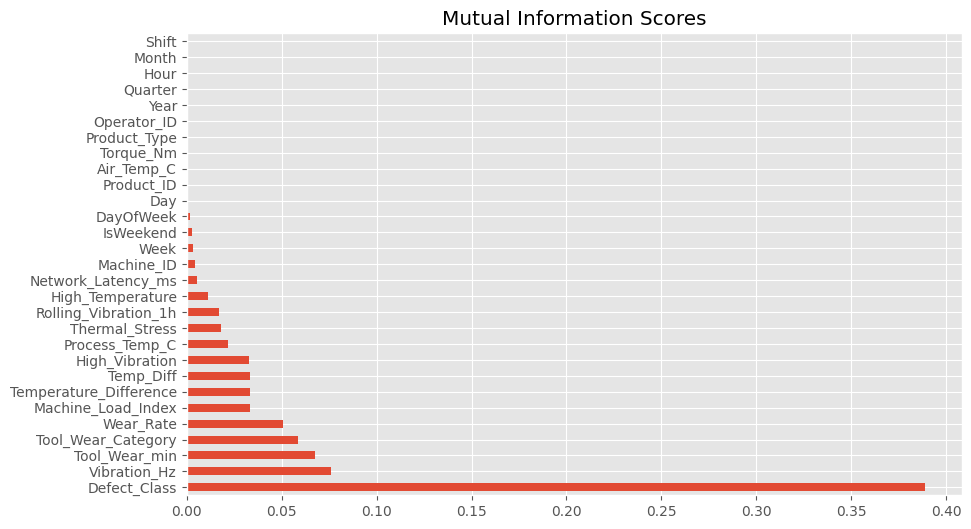

In [54]:
plt.figure(figsize=(10,6))

mi_scores.plot(
    kind="barh"
)

plt.title("Mutual Information Scores")
plt.show()

In [55]:
pca = PCA()

pca.fit(X_scaled)

PCA()

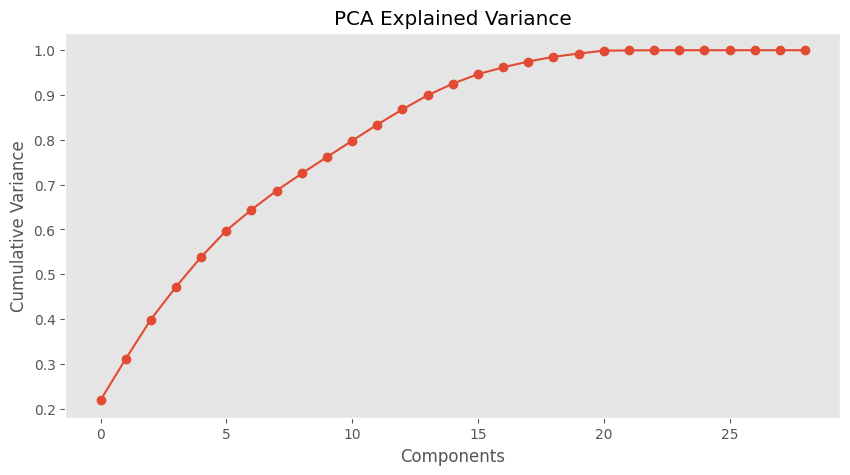

In [56]:
plt.figure(figsize=(10,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="o"
)

plt.xlabel("Components")

plt.ylabel("Cumulative Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

In [57]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(5000, 17)


In [58]:
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)
    wcss.append(km.inertia_)

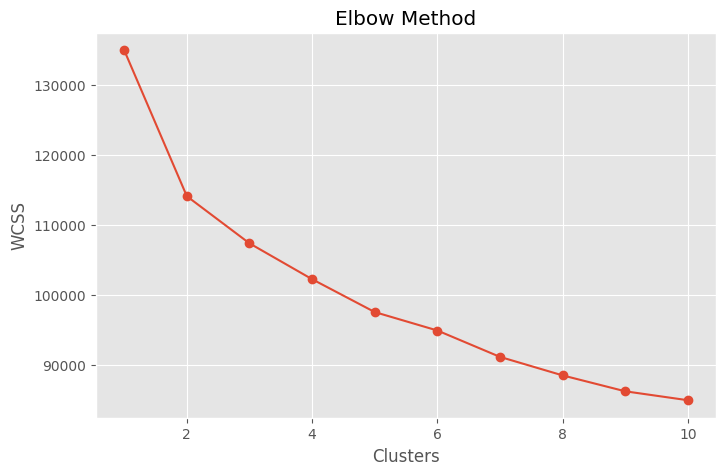

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [60]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

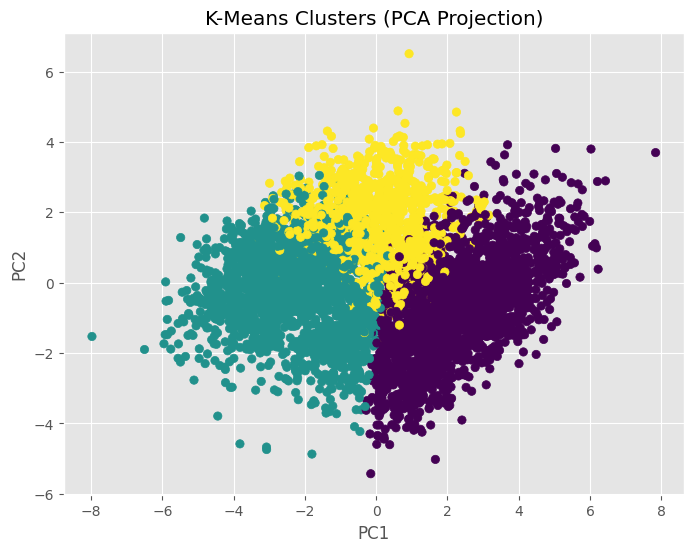

In [61]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")

plt.show()

In [62]:
processed_df = X_scaled.copy()
processed_df["Is_Defective"] = y.values

processed_df.to_csv(
    "manufacturing_processed.csv",
    index=False
)

In [63]:
import joblib

joblib.dump(
    scaler,
    "standard_scaler.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

joblib.dump(
    pca,
    "pca.pkl"
)

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

['kmeans_model.pkl']

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

pd.set_option("display.max_columns", None)

In [65]:
df = pd.read_csv("/content/manufacturing_processed.csv")

In [66]:
df.head()

,Machine_ID,Product_ID,Product_Type,Operator_ID,Air_Temp_C,Process_Temp_C,Vibration_Hz,Network_Latency_ms,Torque_Nm,Tool_Wear_min,Rolling_Vibration_1h,Temp_Diff,Defect_Class,Year,Month,Week,Day,Hour,DayOfWeek,Quarter,IsWeekend,Temperature_Difference,Tool_Wear_Category,High_Vibration,High_Temperature,Machine_Load_Index,Thermal_Stress,Wear_Rate,Shift,Is_Defective
0,0.528826,-1.731704,1.286152,0.002215,-1.853371,-0.921853,-0.549111,-0.497735,0.004291,-0.059863,-1.098955,0.144033,0.158925,0.0,-0.835685,8.172404,-1.594073,-0.505254,1.508173,0.0,1.597228,0.144033,1.023585,-1.0,-1.0,-0.370574,0.107737,-0.096460,0.0,False
1,-0.513675,-1.731012,1.286152,1.155885,1.086519,0.659387,1.065375,-0.092540,-0.863209,0.508440,2.135081,0.058473,2.499494,0.0,-0.835685,8.172404,-1.594073,-0.505254,1.508173,0.0,1.597228,0.058473,-1.221119,1.0,1.0,-0.000612,-0.536303,0.784835,0.0,True
2,0.876327,-1.730319,-0.141954,-0.920721,0.637794,-1.427622,0.191496,-0.539926,-0.483980,-0.905388,0.384582,-2.145702,0.158925,0.0,-0.835685,8.172404,-1.594073,-0.505254,1.508173,0.0,1.597228,-2.145702,-0.098767,1.0,-1.0,-0.226908,-1.765435,-0.818932,0.0,False
3,-0.166175,-1.729626,-0.141954,0.463683,-0.757792,-0.219528,0.697176,0.214146,-1.125509,1.548020,1.397527,0.247970,0.158925,0.0,-0.835685,8.172404,-1.594073,-0.505254,1.508173,0.0,1.597228,0.247970,-1.221119,1.0,-1.0,-0.419133,-0.599686,2.110307,0.0,False
4,0.528826,-1.728933,-0.141954,-0.689987,0.861321,1.313828,0.024007,0.344234,-1.095971,0.744078,-0.524938,0.996731,0.158925,0.0,-0.835685,8.172404,-1.594073,-0.360697,1.508173,0.0,1.597228,0.996731,-1.221119,1.0,1.0,-0.765377,-0.132435,1.169117,0.0,False


In [67]:
df.shape

(5000, 30)

In [68]:
TARGET = "Is_Defective"

X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5000, 29)
Target Shape : (5000,)


In [69]:
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

In [70]:
print("Numerical Features")

print("-"*50)

print(numerical_features)

Numerical Features
--------------------------------------------------
['Machine_ID', 'Product_ID', 'Product_Type', 'Operator_ID', 'Air_Temp_C', 'Process_Temp_C', 'Vibration_Hz', 'Network_Latency_ms', 'Torque_Nm', 'Tool_Wear_min', 'Rolling_Vibration_1h', 'Temp_Diff', 'Defect_Class', 'Year', 'Month', 'Week', 'Day', 'Hour', 'DayOfWeek', 'Quarter', 'IsWeekend', 'Temperature_Difference', 'Tool_Wear_Category', 'High_Vibration', 'High_Temperature', 'Machine_Load_Index', 'Thermal_Stress', 'Wear_Rate', 'Shift']


In [71]:
print("Categorical Features")

print("-"*50)

print(categorical_features)

Categorical Features
--------------------------------------------------
[]


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [73]:
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (4000, 29)
Testing Samples : (1000, 29)


In [74]:
print(y_train.value_counts(normalize=True))
print()
print(y_test.value_counts(normalize=True))

Is_Defective
False    0.86875
True     0.13125
Name: proportion, dtype: float64

Is_Defective
False    0.869
True     0.131
Name: proportion, dtype: float64


In [75]:
numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [76]:
categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

In [77]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numerical_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]

)

In [78]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [79]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(4000, 29)
(1000, 29)


In [80]:
joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Preprocessor Saved Successfully")

Preprocessor Saved Successfully


In [81]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc = roc_auc_score(
        y_test,
        probabilities
    )

    print("="*60)

    print(model.__class__.__name__)

    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC AUC : {roc:.4f}")

    print()

    print(classification_report(
        y_test,
        predictions
    ))

    return {

        "Model":model.__class__.__name__,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "ROC":roc

    }

In [82]:
results = pd.DataFrame(

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC"

    ]

)

In [83]:
print("="*60)
print("Training Dataset :", X_train_processed.shape)
print("Testing Dataset :", X_test_processed.shape)
print("Target Distribution")
print(y_train.value_counts())
print("="*60)

Training Dataset : (4000, 29)
Testing Dataset : (1000, 29)
Target Distribution
Is_Defective
False    3475
True      525
Name: count, dtype: int64


In [84]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

In [85]:
logistic_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             random_state=42,
             max_iter=1000
         )
        )

    ]

)

In [86]:
decision_tree_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         DecisionTreeClassifier(
             random_state=42
         )
        )

    ]

)

In [87]:
random_forest_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         RandomForestClassifier(

             n_estimators=200,

             random_state=42,

             n_jobs=-1

         )
        )

    ]

)

In [88]:
svm_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         SVC(

             probability=True,

             random_state=42

         )
        )

    ]

)

In [89]:
xgb_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

         XGBClassifier(

             random_state=42,

             eval_metric="logloss",

             use_label_encoder=False

         )
        )

    ]

)

In [90]:
models = {

    "Logistic Regression": logistic_pipeline,

    "Decision Tree": decision_tree_pipeline,

    "Random Forest": random_forest_pipeline,

    "Support Vector Machine": svm_pipeline,

    "XGBoost": xgb_pipeline

}

In [91]:
results = []

for name, model in models.items():

    print("="*80)

    print(f"Training {name}")

    print("="*80)

    model.fit(

        X_train,

        y_train

    )

    prediction = model.predict(

        X_test

    )

    probability = model.predict_proba(

        X_test

    )[:,1]

    accuracy = accuracy_score(

        y_test,

        prediction

    )

    precision = precision_score(

        y_test,

        prediction

    )

    recall = recall_score(

        y_test,

        prediction

    )

    f1 = f1_score(

        y_test,

        prediction

    )

    roc = roc_auc_score(

        y_test,

        probability

    )

    results.append({

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "ROC AUC":roc

    })

    print(classification_report(

        y_test,

        prediction

    ))

Training Logistic Regression
              precision    recall  f1-score   support

       False       0.92      0.99      0.95       869
        True       0.86      0.43      0.57       131

    accuracy                           0.92      1000
   macro avg       0.89      0.71      0.76      1000
weighted avg       0.91      0.92      0.90      1000

Training Decision Tree
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       869
        True       1.00      1.00      1.00       131

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Training Random Forest
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       869
        True       1.00      1.00      1.00       131

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000

In [92]:
results_df = pd.DataFrame(

    results

)

results_df.sort_values(

    "F1 Score",

    ascending=False,

    inplace=True

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.000,1.000000,1.000000,1.000000,1.000000
4,XGBoost,1.000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000,1.000000
3,Support Vector Machine,0.953,1.000000,0.641221,0.781395,0.999332
0,Logistic Regression,0.916,0.861538,0.427481,0.571429,0.808484


In [93]:
results_df.style.background_gradient(

    cmap="Greens"

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
4,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Support Vector Machine,0.953000,1.000000,0.641221,0.781395,0.999332
0,Logistic Regression,0.916000,0.861538,0.427481,0.571429,0.808484


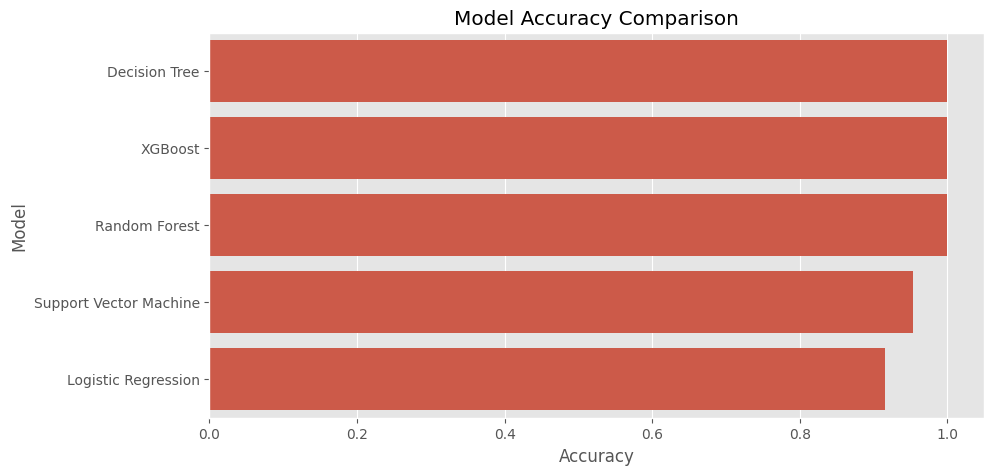

In [94]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model"

)

plt.title(

    "Model Accuracy Comparison"

)

plt.show()

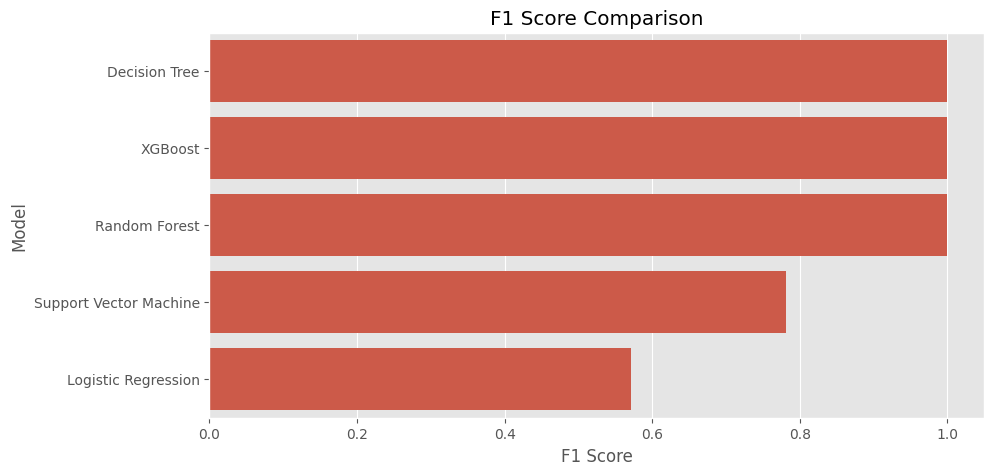

In [95]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="F1 Score",

    y="Model"

)

plt.title(

    "F1 Score Comparison"

)

plt.show()

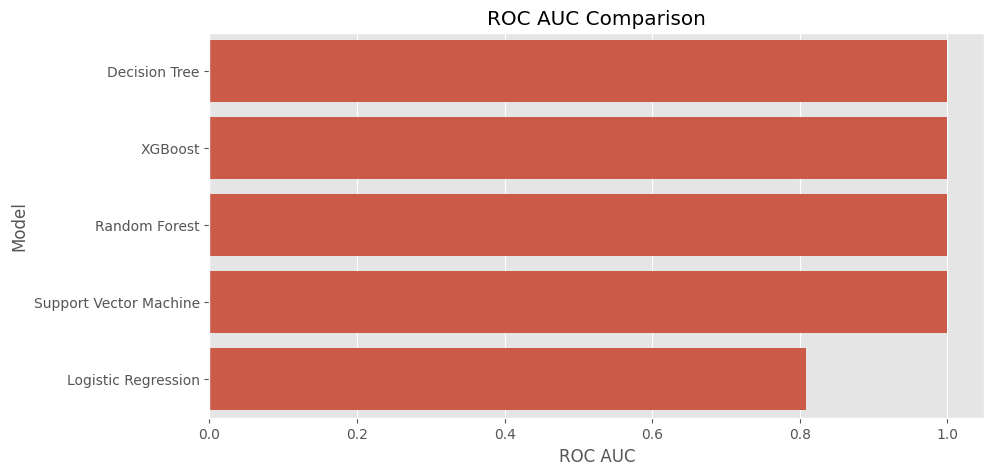

In [96]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="ROC AUC",

    y="Model"

)

plt.title(

    "ROC AUC Comparison"

)

plt.show()

In [97]:
best_model_name = results_df.iloc[0]["Model"]

print(

    f"Best Model : {best_model_name}"

)

Best Model : Decision Tree


In [98]:
best_pipeline = models[

    best_model_name

]

joblib.dump(

    best_pipeline,

    "best_baseline_model.pkl"

)

print(

    "Best Baseline Model Saved"

)

Best Baseline Model Saved


In [99]:
results_df.reset_index(

    drop=True,

    inplace=True

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,1.000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,1.000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000,1.000000
3,Support Vector Machine,0.953,1.000000,0.641221,0.781395,0.999332
4,Logistic Regression,0.916,0.861538,0.427481,0.571429,0.808484
